# Epic of Sun - Desafio 1
Training  the model.
***

This jupyter notebook trains a UNet for sugarcane identification from satellite images.

It is divided in 7 parts:
* Loading libraries
* Loading data
* Separating in train, validate, and test datasets
* Build the model
* Train the model
* Evaluate the model
* Check results

# Sugarcane training
***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import rasterio
from rasterio.features import rasterize

import json
import joblib
from pathlib import Path
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

2026-07-22 00:42:58.483638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784691778.624694  482024 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784691778.663849  482024 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-22 00:42:59.007982: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Get the directory where THIS script is located
base_path = Path.cwd()

In [3]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

In [4]:
patch_index = pd.read_csv(patches_path / "patch_index.csv" )

print(patch_index.head())
print(len(patch_index))

              scene  patch  row  col                       image_file  \
0  Sertãozinho_test      0    0    0  Sertãozinho_test_patch00000.npy   
1  Sertãozinho_test      1    0   64  Sertãozinho_test_patch00001.npy   
2  Sertãozinho_test      2    0  128  Sertãozinho_test_patch00002.npy   
3  Sertãozinho_test      3    0  192  Sertãozinho_test_patch00003.npy   
4  Sertãozinho_test      4    0  256  Sertãozinho_test_patch00004.npy   

                         mask_file  
0  Sertãozinho_test_patch00000.npy  
1  Sertãozinho_test_patch00001.npy  
2  Sertãozinho_test_patch00002.npy  
3  Sertãozinho_test_patch00003.npy  
4  Sertãozinho_test_patch00004.npy  
1368


In [5]:
# For now, since you have only one Sentinel scene, a random split is acceptable.
# Later, when you have multiple scenes, you'll split by scene, not by patch.

# Split the dataset into training, validation, and test sets
train_df, test_df = train_test_split(
    patch_index,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [6]:
# Function to load the patches individually
def load_dataset(df, image_folder, mask_folder):

    X = []
    Y = []

    for _, row in df.iterrows():

        x = np.load(image_folder / row["image_file"]).astype(np.float32)
        y = np.load(mask_folder / row["mask_file"]).astype(np.float32)

        X.append(x)
        Y.append(y)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    Y = Y[..., np.newaxis]

    return X, Y

In [7]:
image_folder = patches_path / "images"
mask_folder = patches_path / "masks"

X_train, y_train = load_dataset(train_df, image_folder, mask_folder)
X_val, y_val = load_dataset(val_df, image_folder, mask_folder)
X_test, y_test = load_dataset(test_df, image_folder, mask_folder)

In [8]:
print(X_train.shape)
print(y_train.shape)

print(X_train.dtype)
print(y_train.dtype)

print(np.unique(y_train))

(875, 128, 128, 4)
(875, 128, 128, 1)
float32
float32
[0. 1.]


In [9]:
print(patch_index.iloc[0])

scene                        Sertãozinho_test
patch                                       0
row                                         0
col                                         0
image_file    Sertãozinho_test_patch00000.npy
mask_file     Sertãozinho_test_patch00000.npy
Name: 0, dtype: object


### The model

In [ ]:
# Convolution block
# Each block performs Conv -> ReLU -> Conv -> ReLU

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x

In [11]:
# Encoder block
# Each block performs:
# extracts features
# saves them for the skip connection
# downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [12]:
# Decoder block
# Each block performs:
# upsamples
# concatenates the skip connection
# performs two convolutions

def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)
	
    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

In [13]:
# Build the network
def build_unet(input_shape=(128,128,4)):

    inputs = layers.Input(input_shape)
    #
    # Encoder
    #
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)
    #
    # Bottleneck
    #
    b1 = conv_block(p4, 512)
    #
    # Decoder
    #
    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)
    #
    # Output
    #
    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(d4)

    return Model(inputs, outputs)

In [14]:
# Create the model
model = build_unet()

model.summary()

I0000 00:00:1784691786.964387  482024 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,760,385 (29.60 MB)

 Trainable params: 7,760,385 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    #metrics=["accuracy"]
	metrics=[
    tf.keras.metrics.BinaryAccuracy(),
    tf.keras.metrics.Precision(),
    tf.keras.metrics.Recall()
]
)

# Save a picture of the model architecture
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    dpi=100
)

In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_unet.keras",
    monitor="val_loss",
    save_best_only=True
)

In [17]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [18]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [19]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))

2.18.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
print(X_train.shape)
print(X_train.dtype)

print(y_train.shape)
print(y_train.dtype)

(875, 128, 128, 4)
float32
(875, 128, 128, 1)
float32


In [ ]:
# train
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/30


I0000 00:00:1784691792.989036  482734 service.cc:148] XLA service 0x74fecc00f030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784691792.989553  482734 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-07-22 00:43:13.125293: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784691793.747988  482734 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/55 ━━━━━━━━━━━━━━━━━━━━ 14:22 16s/step - binary_accuracy: 0.6515 - loss: 0.6916 - precision: 0.7978 - recall: 0.7441

I0000 00:00:1784691804.778209  482734 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 333ms/step - binary_accuracy: 0.7379 - loss: 0.5283 - precision: 0.7330 - recall: 0.9858 - val_binary_accuracy: 0.7693 - val_loss: 0.5220 - val_precision: 0.9265 - val_recall: 0.7273 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - binary_accuracy: 0.8579 - loss: 0.3603 - precision: 0.8673 - recall: 0.9418 - val_binary_accuracy: 0.8623 - val_loss: 0.3515 - val_precision: 0.8474 - val_recall: 0.9791 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - binary_accuracy: 0.8750 - loss: 0.3263 - precision: 0.8843 - recall: 0.9458 - val_binary_accuracy: 0.8817 - val_loss: 0.3148 - val_precision: 0.9039 - val_recall: 0.9295 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - binary_accuracy: 0.8818 - loss: 0.3095 - precision: 0.8916 - recall: 0.9467 - val_binary_accuracy: 0.8865 - val_loss: 0.2981 - val_precision: 0.9058 - val_recall: 0.9347 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━

In [ ]:
# save
model.save(base_path / "models" / "unet_sugarcane.keras")

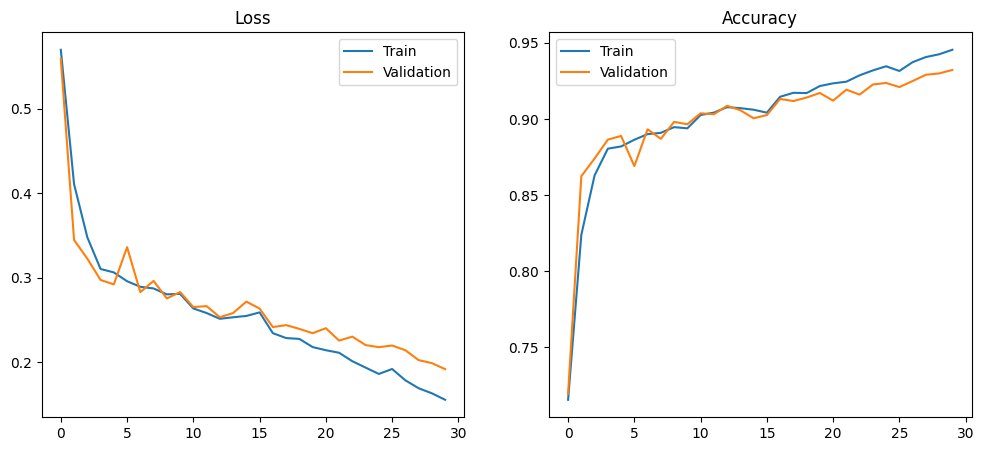

In [ ]:
# plot the learning curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["binary_accuracy"], label="Train")
plt.plot(history.history["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.show()

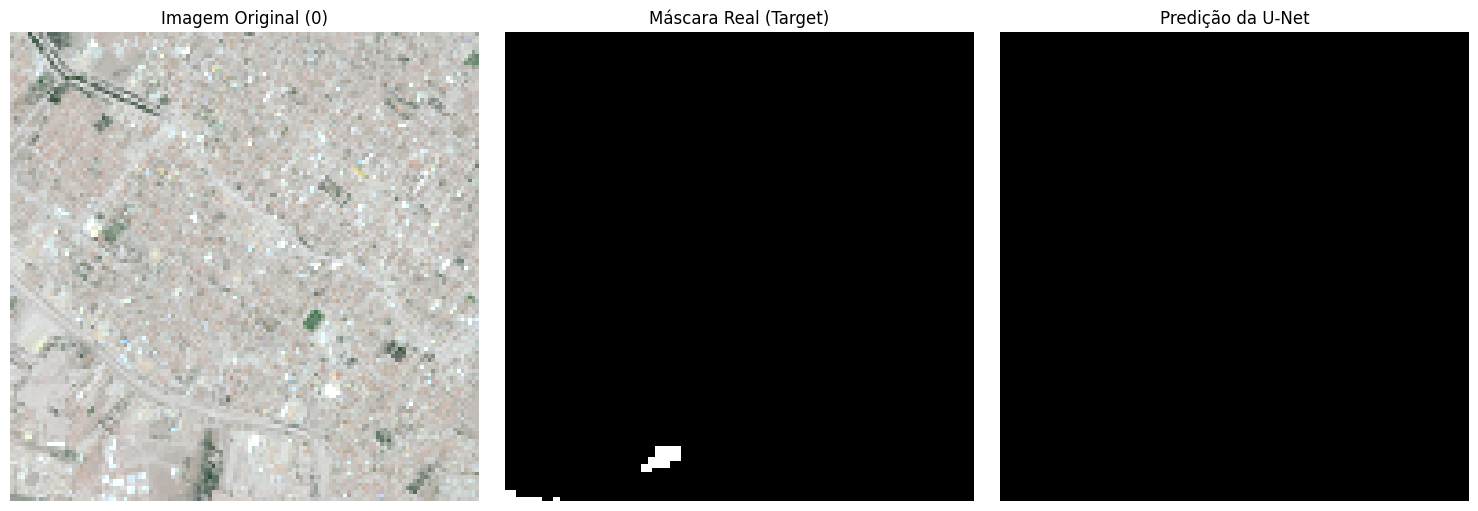

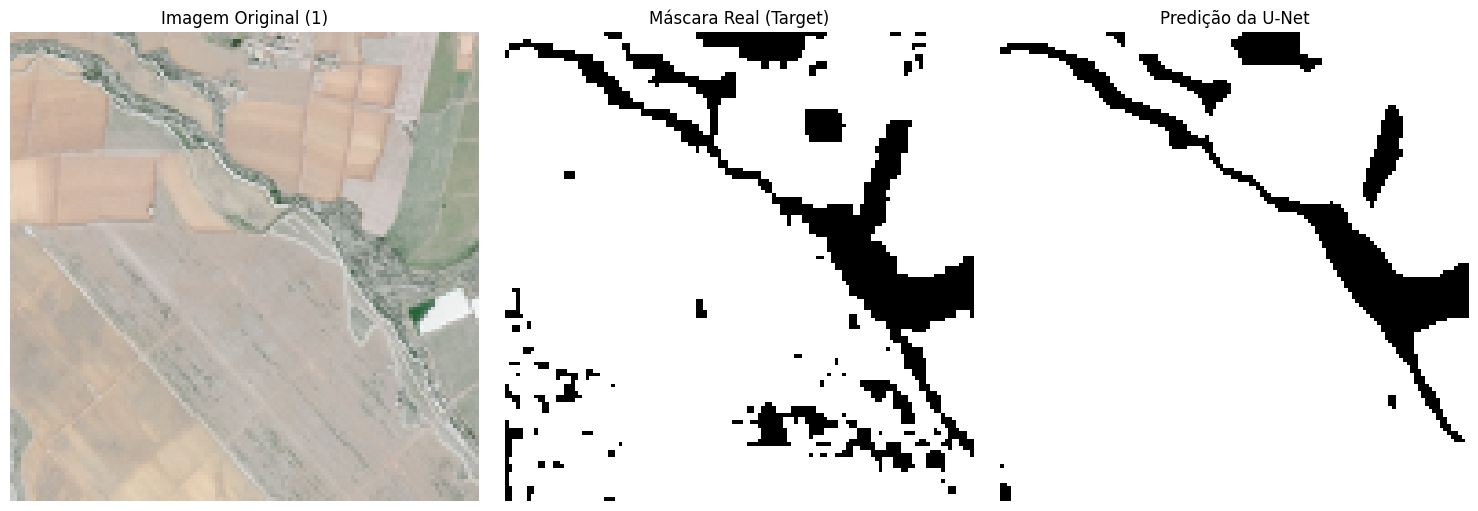

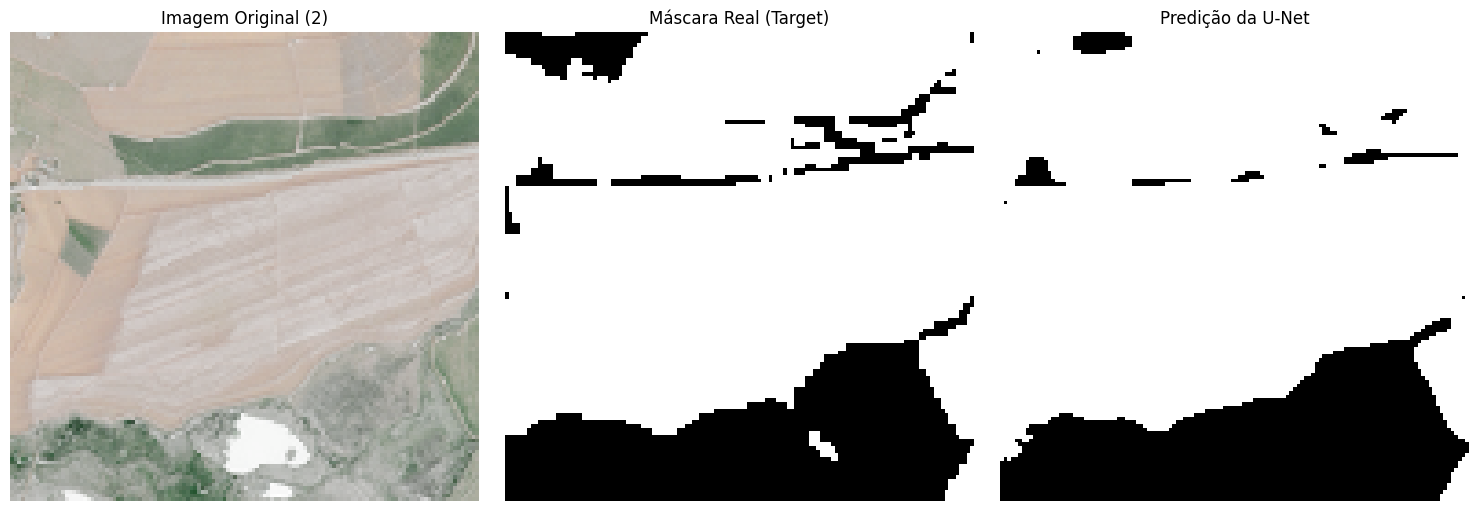

In [ ]:

# Defina quantas amostras você quer visualizar para teste
max_plots = 4

for i in range(len(X_train)):
    # 1. Extrai a imagem e faz a predição
    single_img = X_train[i][np.newaxis, ...]
    pred = model.predict(single_img, verbose=0)
    
    # Remove a dimensão de lote da predição
    pred_squeezed = pred[0]
    prediction = pred_squeezed > 0.5
    
    # 2. CONFIGURAÇÃO DA VISUALIZAÇÃO (Apenas para as primeiras X imagens)
    if i < max_plots:
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        
        # [0] Imagem Original (Extraída diretamente do seu X_train)
        # Se X_train tiver formato (H, W, C), basta passar X_train[i]
        ax[0].imshow(X_train[i])
        ax[0].set_title(f"Imagem Original ({i})")
        ax[0].axis('off')
        
        # [1] Máscara Real (Gabarito / Ground Truth)
        # Substitua 'y_train' pelo nome real da sua variável de máscaras
        ax[1].imshow(y_train[i].squeeze(), cmap='gray')
        ax[1].set_title("Máscara Real (Target)")
        ax[1].axis('off')
        
        # [2] Predição da U-Net
        ax[2].imshow(prediction.squeeze(), cmap='gray')
        ax[2].set_title("Predição da U-Net")
        ax[2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    # Se você ainda quiser guardar todas as predições na memória:
    # predictions.append(pred_squeezed)


In [ ]:
# 1. Transforme as predições contínuas em booleanas/binárias (0 ou 1)
# Certifique-se de que y_true também seja binário (0 ou 1)
y_pred_bin = (predictions > 0.5).astype(int)
y_true_bin = y_train.astype(int) # substitua y_train pela sua variável real

# 2. Aplate as matrizes para o formato 1D (vetor de pixels)
y_true_flat = y_true_bin.ravel()
y_pred_flat = y_pred_bin.ravel()

# 3. Calcule as métricas globalmente para todo o dataset
p = precision_score(y_true_flat, y_pred_flat, zero_division=0)
r = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

print(f"Precision: {p:.4f}")
print(f"Recall:    {r:.4f}")
print(f"F1-Score:  {f1:.4f}")

Precision: 0.9512
Recall:    0.9756
F1-Score:  0.9633


In [ ]:
intersection = np.logical_and(
    y_true_flat,
    y_pred_flat
)

union = np.logical_or(
    y_true_flat,
    y_pred_flat
)

iou = intersection.sum() / union.sum()
print(f"IoU:       {iou:.4f}")

IoU:       0.9292


In [ ]:
dice = (
    2 * intersection.sum()
) / (
    y_true_flat.sum() +
    y_pred_flat.sum()
)
print(f"Dice Coefficient: {dice:.4f}")

Dice Coefficient: 0.9633
